In [2]:
import pandas as pd 

df = pd.read_csv("climate_nasa.csv")

9df.head()

,date,likesCount,profileName,commentsCount,text
0,2022-09-07T17:12:32.000Z,2,4dca617d86b3fdce80ba7e81fb16e048c9cd9798cdfd6d...,NaN,Neat comparison I have not heard it before.\n ...
1,2022-09-08T14:51:13.000Z,0,518ab97f2d115ba5b6f03b2fba2ef2b120540c9681288b...,NaN,An excellent way to visualise the invisible! T...
2,2022-09-07T17:19:41.000Z,1,d82e8e24eb633fd625b0aef9b3cb625cfb044ceb8483e1...,3.0,Does the CO2/ghg in the troposphere affect the...
3,2022-09-08T00:51:30.000Z,4,37a509fa0b5177a2233c7e2d0e2b2d6916695fa9fba3f2...,NaN,excellent post! I defo feel the difference - o...
4,2022-09-07T19:06:20.000Z,16,e54fbbd42a729af9d04d9a5cc1f9bbfe8081a31c219ecb...,26.0,"Yes, and carbon dioxide does not harm the Eart..."


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           522 non-null    object 
 1   likesCount     522 non-null    int64  
 2   profileName    522 non-null    object 
 3   commentsCount  244 non-null    float64
 4   text           504 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 20.5+ KB


In [4]:
df.describe()

,likesCount,commentsCount
count,522.000000,244.000000
mean,4.720307,8.696721
std,12.053556,12.266176
min,0.000000,1.000000
25%,0.000000,2.000000
50%,1.000000,5.000000
75%,4.000000,10.000000
max,126.000000,93.000000


In [6]:
X = df.drop(columns=["likesCount"])  
y = df["likesCount"]  

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (522, 4)
Labels shape: (522,)


In [7]:
X = df.drop(columns=["commentsCount"])  
y = df["commentsCount"]  

# Display shapes
print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (522, 4)
Labels shape: (522,)


In [8]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop(columns=["likesCount"])  # Features (all except target)
y = df["likesCount"]  # Target variable

# Split into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print shapes to confirm the split
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Training Features Shape: (417, 4)
Testing Features Shape: (105, 4)
Training Labels Shape: (417,)
Testing Labels Shape: (105,)


In [9]:
from sklearn.preprocessing import StandardScaler

# Select numerical features only (excluding 'profileName' and 'text')
numerical_cols = ["commentsCount"]  # Add more numerical columns if needed
X_num = df[numerical_cols].fillna(0)  # Fill NaNs before scaling

# Initialize and apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# Convert back to DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=numerical_cols)

# Display first few rows
print(X_scaled_df.head())

   commentsCount
0      -0.431220
1      -0.431220
2      -0.112987
3      -0.431220
4       2.326800


In [13]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd

# Load the dataset
file_path = "C:\\Users\\Vaibhav Rathod\\Desktop\\Nilay\\Data Science Internship Projects\\Data Analyst & Data Science\\Projects\\Climate Change Modeling\\climate_nasa.csv"
df = pd.read_csv(file_path)

# Handle missing values correctly (Fix for FutureWarning)
df["commentsCount"] = df["commentsCount"].fillna(0)  # No inplace warning

# Select features and target
X = df[["commentsCount"]]  # Features (numerical only)
y = df["likesCount"]  # Target variable

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Print results
print("✅ Model trained successfully!")
print(f"📊 Mean Absolute Error: {mae:.2f}")
print(f"📉 Mean Squared Error: {mse:.2f}")

✅ Model trained successfully!
📊 Mean Absolute Error: 4.83
📉 Mean Squared Error: 153.33


In [15]:
# Example for Linear Regression
from sklearn.linear_model import LinearRegression

# Assuming X_train and y_train are pandas DataFrames with feature names
model = LinearRegression()
model.fit(X_train, y_train)

# Now the model is trained with feature names
predictions = model.predict(X_test)

In [17]:
# Assuming X_train and X_test are both pandas DataFrames
# Ensure that X_test has the same columns as X_train
X_test = X_test[X_train.columns]

# Now you can make predictions
predictions = model.predict(X_test)

In [18]:
from sklearn.metrics import mean_squared_error, r2_score

# Assuming you have the true values of the target variable in y_test
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 153.33039570590932
R-squared: 0.1466034557251864


In [20]:
from sklearn.metrics import mean_squared_error, r2_score

# Assuming predictions are continuous values (e.g., predicted prices)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 153.33039570590932
R-squared: 0.1466034557251864


In [21]:
# If your model predicts probabilities, convert them to class labels
# For binary classification, use 0.5 as a threshold
predictions_class = (predictions > 0.5).astype(int)

# Now you can use classification metrics
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, predictions_class)
conf_matrix = confusion_matrix(y_test, predictions_class)

print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")

Accuracy: 0.1619047619047619
Confusion Matrix:
[[ 0 53  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  6  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  7  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Example dataset (assuming X and y are already defined and preprocessed)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, predictions)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 154.8386165373604


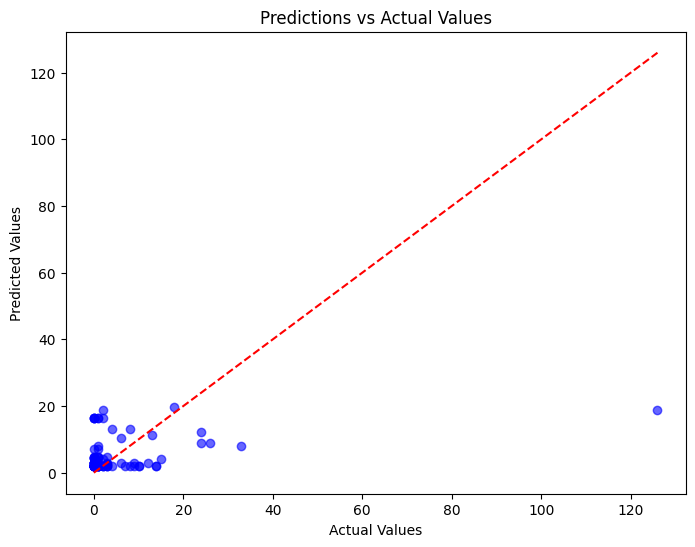

In [23]:
import matplotlib.pyplot as plt

# Scatter plot for Predictions vs Actual values
plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions, color='blue', alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Ideal line
plt.title('Predictions vs Actual Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

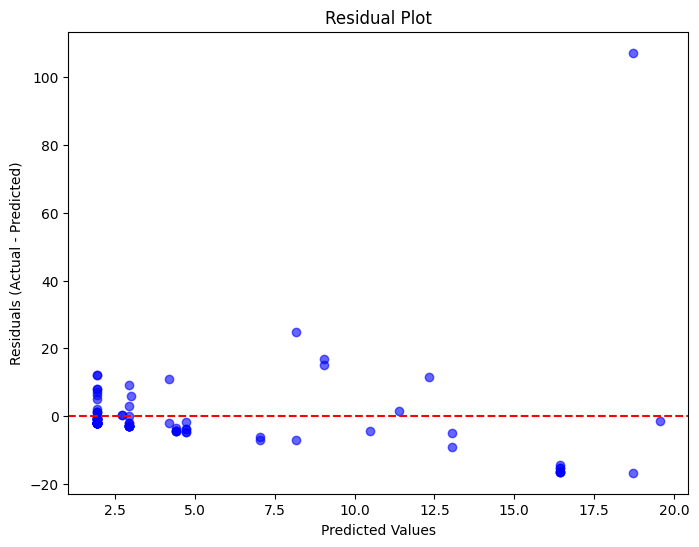

In [24]:
# Residual Plot
residuals = y_test - predictions
plt.figure(figsize=(8,6))
plt.scatter(predictions, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')  # Line at 0 for residuals
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

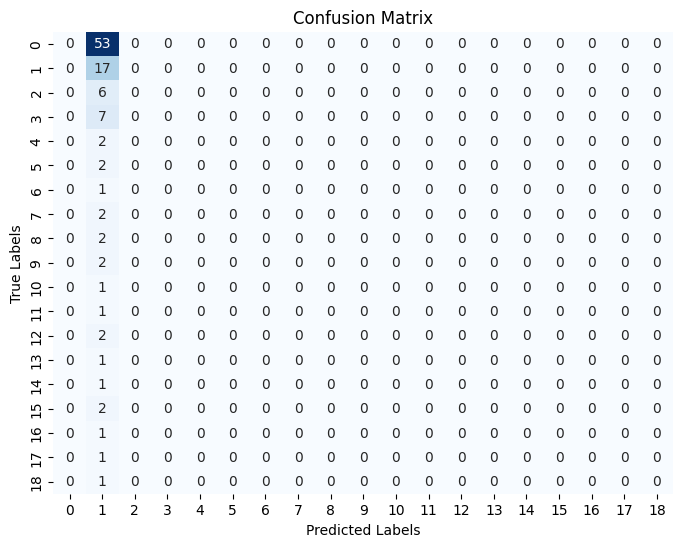

In [26]:
# Convert probabilities to binary class labels (0 or 1)
predictions_class = (predictions > 0.5).astype(int)

# Now you can plot the confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

conf_matrix = confusion_matrix(y_test, predictions_class)

# Plot Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()